<a href="https://colab.research.google.com/github/KrushnaTaur/IN226056702_NLP/blob/main/Task_2_Sentiment_Analysis_NLP_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
# Use this dataset (works in Colab)
url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"

df = pd.read_csv(url)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [w for w in tokens if len(w) > 2 or w in ['no', 'not']]

    return " ".join(tokens)

In [14]:
df['clean_review'] = df['review'].apply(preprocess_text)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one the other reviewers has mentioned that aft...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production the filming techni...
2,I thought this was a wonderful way to spend ti...,positive,thought this was wonderful way spend time too ...
3,Basically there's a family where a little boy ...,negative,basically theres family where little boy jake ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love the time money visually st...


In [15]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [19]:
# Predictions
lr_pred = lr_model.predict(X_test)
nb_pred = nb_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Logistic Regression Accuracy: 0.8916
Naive Bayes Accuracy: 0.8524


In [20]:
print("Logistic Regression Report:\n", classification_report(y_test, lr_pred))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



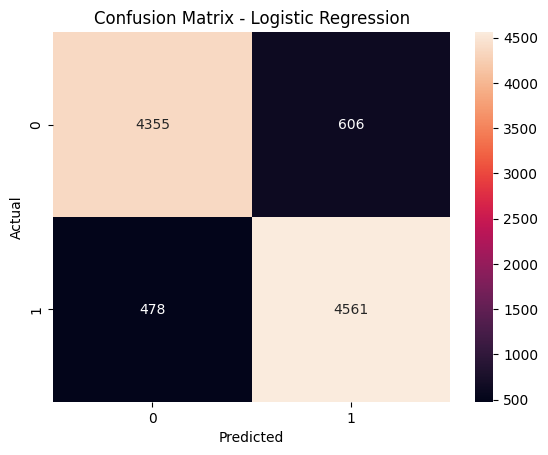

In [21]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
def predict_sentiment(text):
    text = preprocess_text(text)
    vec = vectorizer.transform([text])
    pred = lr_model.predict(vec)

    return "Positive 😊" if pred[0] == 1 else "Negative 😡"

# Test
print(predict_sentiment("This movie was absolutely amazing!"))
print(predict_sentiment("Worst experience ever"))

Positive 😊
Negative 😡


In [23]:
models = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Naive Bayes": accuracy_score(y_test, nb_pred)
}

print(models)

{'Logistic Regression': 0.8916, 'Naive Bayes': 0.8524}
